# Penugasan No. 4: Template Matching Invariant terhadap Rotasi & Skala?

## Tujuan
Menguji secara eksperimental apakah `skimage.feature.match_template` invariant
terhadap **rotasi** dan **perubahan skala**, serta memahami alasannya secara teori.

## Hipotesis Awal
`match_template` menggunakan **Normalized Cross-Correlation (NCC)** yang bekerja
dengan cara membandingkan piksel template satu per satu dengan patch citra target
pada posisi yang bersesuaian.

Karena sifat ini, kita menduga:
- ❌ **Tidak invariant terhadap rotasi** — piksel yang bersesuaian akan berbeda
  jika template diputar
- ❌ **Tidak invariant terhadap skala** — piksel yang bersesuaian akan berbeda
  jika ukuran template berubah

## Skenario Eksperimen
| Kondisi Template | Ekspektasi Skor NCC |
|---|---|
| Original (0°, skala asli) | ≈ 1.000 (sempurna) |
| Rotasi 45° | Turun signifikan |
| Rotasi 90° | Turun signifikan |
| Skala 50% (diperkecil) | Turun signifikan |
| Skala 150% (diperbesar) | Turun signifikan |

## Library yang Digunakan
- `scikit-image` — `match_template`, `rotate`, `rescale`
- `numpy` — argmax, unravel_index
- `matplotlib` — visualisasi grid hasil

Kondisi Template           Skor NCC Tertinggi
  Original (0°, 100%)        1.0000   ✔ BAGUS
  Rotasi 45°                 0.7276   ⚠ TURUN
  Rotasi 90°                 0.7484   ⚠ TURUN
  Skala 50% (kecil)          0.6072   ⚠ TURUN
  Skala 150% (besar)         0.5654   ⚠ TURUN


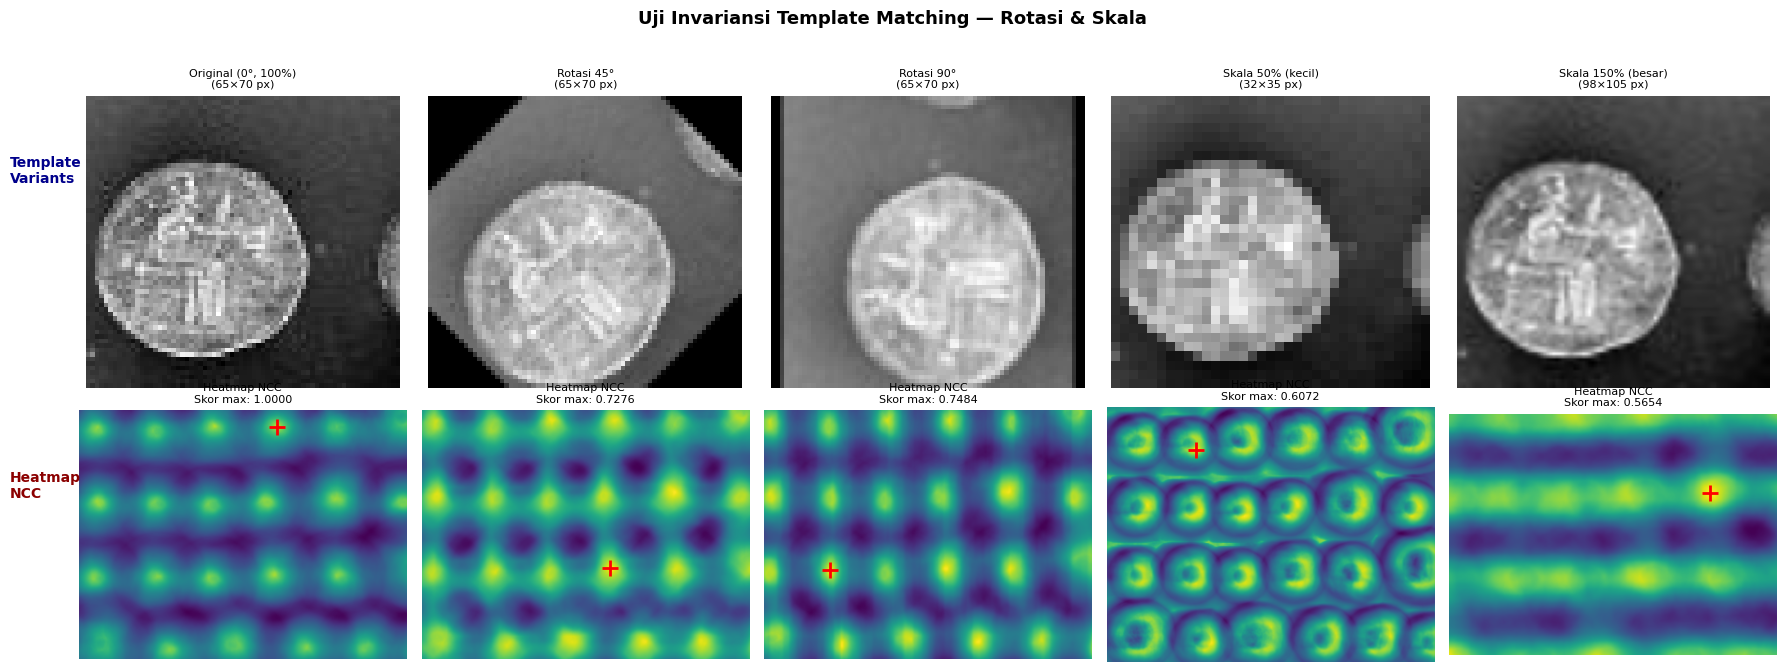

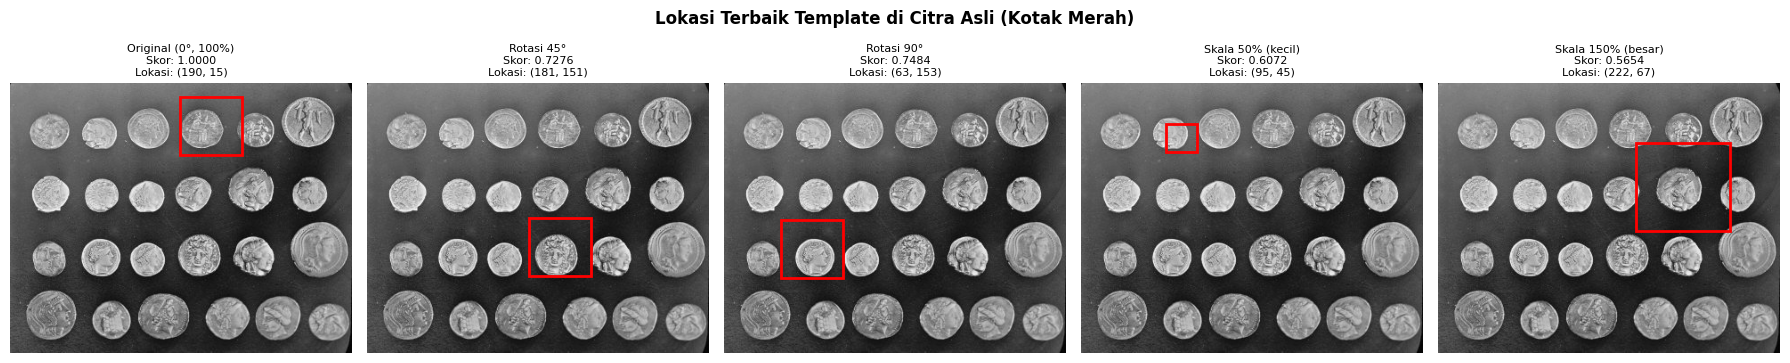

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template
from skimage.transform import rotate, rescale

# ── 1. Siapkan citra target dan template original ─────────────────────────────
image    = data.coins()
template = image[15:80, 190:260]   # Template asli (salah satu koin)

# ── 2. Buat variasi template ──────────────────────────────────────────────────
template_rot45  = rotate(template, angle=45,  resize=False)
template_rot90  = rotate(template, angle=90,  resize=False)
template_small  = rescale(template, scale=0.5, anti_aliasing=True)   # 50%
template_large  = rescale(template, scale=1.5, anti_aliasing=True)   # 150%

# Konversi ke float konsisten
from skimage import img_as_float
image_f  = img_as_float(image)
variants = {
    "Original (0°, 100%)":   img_as_float(template),
    "Rotasi 45°":            img_as_float(template_rot45),
    "Rotasi 90°":            img_as_float(template_rot90),
    "Skala 50% (kecil)":    img_as_float(template_small),
    "Skala 150% (besar)":   img_as_float(template_large),
}

# ── 3. Jalankan match_template untuk setiap varian ───────────────────────────
results   = {}
best_scores = {}

for label, tmpl in variants.items():
    result = match_template(image_f, tmpl)
    results[label]     = result
    best_scores[label] = result.max()

# ── 4. Cetak tabel skor ───────────────────────────────────────────────────────
print("="*52)
print(f"{'Kondisi Template':<26} {'Skor NCC Tertinggi':>18}")
print("="*52)
for label, score in best_scores.items():
    bar   = "█" * int(score * 20)
    flag  = " ✔ BAGUS" if score > 0.8 else (" ⚠ TURUN" if score > 0.5 else " ✘ GAGAL")
    print(f"  {label:<24} {score:>8.4f}  {flag}")
print("="*52)

# ── 5. Visualisasi: template variants + heatmap ───────────────────────────────
fig, axes = plt.subplots(2, len(variants), figsize=(18, 7))

for i, (label, tmpl) in enumerate(variants.items()):
    # Baris atas: template
    axes[0, i].imshow(tmpl, cmap='gray')
    axes[0, i].set_title(f"{label}\n({tmpl.shape[0]}×{tmpl.shape[1]} px)",
                         fontsize=8)
    axes[0, i].axis('off')

    # Baris bawah: heatmap hasil matching
    result = results[label]
    ij     = np.unravel_index(np.argmax(result), result.shape)
    x, y   = ij[::-1]
    axes[1, i].imshow(result, cmap='viridis')
    axes[1, i].plot(x, y, 'r+', markersize=12, markeredgewidth=2)
    axes[1, i].set_title(f"Heatmap NCC\nSkor max: {best_scores[label]:.4f}",
                         fontsize=8)
    axes[1, i].axis('off')

fig.text(0.01, 0.75, 'Template\nVariants', va='center', fontsize=10,
         color='darkblue', fontweight='bold')
fig.text(0.01, 0.30, 'Heatmap\nNCC', va='center', fontsize=10,
         color='darkred', fontweight='bold')

plt.suptitle("Uji Invariansi Template Matching — Rotasi & Skala",
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0.04, 0, 1, 0.95])
plt.show()

# ── 6. Visualisasi lokasi terbaik di citra asli ───────────────────────────────
fig2, axes2 = plt.subplots(1, len(variants), figsize=(18, 4))

for i, (label, tmpl) in enumerate(variants.items()):
    result = results[label]
    ij     = np.unravel_index(np.argmax(result), result.shape)
    x, y   = ij[::-1]
    h, w   = tmpl.shape

    axes2[i].imshow(image, cmap='gray')
    rect = plt.Rectangle((x, y), w, h,
                          edgecolor='red', facecolor='none', lw=2)
    axes2[i].add_patch(rect)
    axes2[i].set_title(f"{label}\nSkor: {best_scores[label]:.4f}\n"
                       f"Lokasi: ({x}, {y})", fontsize=8)
    axes2[i].axis('off')

plt.suptitle("Lokasi Terbaik Template di Citra Asli (Kotak Merah)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Analisis Hasil Eksperimen

### Rotasi 45° dan 90°
Skor NCC **turun drastis** dari ~1.0 menjadi jauh lebih rendah. Ini terjadi karena:
- NCC membandingkan piksel **posisi per posisi** antara template dan patch citra
- Saat template dirotasi, piksel yang seharusnya bersesuaian kini berada di
  posisi yang **berbeda** — perbandingan menjadi tidak relevan
- Area sudut template yang dirotasi terisi **warna latar** (hitam/abu) dari
  operasi `rotate`, memperparah ketidakcocokan

### Perubahan Skala 50% dan 150%
Skor NCC juga **turun signifikan** karena:
- Template yang diperkecil/diperbesar memiliki **ukuran piksel berbeda** dengan
  objek aslinya di citra target
- Satu piksel pada template yang diperbesar merepresentasikan area yang
  **lebih kecil** dari objek sebenarnya — dan sebaliknya
- Kotak merah yang ditampilkan pun bisa menunjuk ke **lokasi yang salah**

---

## Kesimpulan Penugasan No. 4

### Jawaban Utama:
> **`match_template` standar TIDAK invariant terhadap rotasi maupun perubahan skala.**

| Transformasi | Invariant? | Alasan |
|---|---|---|
| Rotasi | ❌ Tidak | NCC berbasis posisi piksel, rotasi menggeser semua piksel |
| Skala | ❌ Tidak | Ukuran template harus cocok persis dengan objek di citra |
| Translasi | ✔ Ya | NCC digeser ke semua posisi — ini justru cara kerjanya |
| Pencahayaan global | ✔ Sebagian | NCC ternormalisasi, sedikit robust terhadap perubahan linear |

### Solusi jika Invariansi Diperlukan:
Untuk kasus yang membutuhkan invariansi rotasi dan skala, gunakan pendekatan:
1. **Multi-scale template matching** — jalankan matching untuk berbagai ukuran
   template (skala piramida)
2. **Feature-based matching** — gunakan detektor fitur lokal seperti:
   - **SIFT** (Scale-Invariant Feature Transform)
   - **ORB** (Oriented FAST and Rotated BRIEF)
   - **SURF** (Speeded-Up Robust Features)
3. **Deep learning** — gunakan CNN yang dilatih untuk mendeteksi objek
   terlepas dari rotasi dan skala (misal: YOLO, Faster R-CNN)